# Tarea 4. Muestreo de distribuciones

<img style="float: right; margin: 0px 0px 15px 15px;" src="https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png" width="200px" height="180px" />

En esta cuarta tarea, reforzaremos el muestreo de distribuciones usando los métodos vistos en clase.

Recuerda que ante cualquier duda, me puedes contactar al correo esjimenezro@iteso.mx.

<p style="text-align:right;"> Imagen recuperada de: https://storage.needpix.com/rsynced_images/bayesian-2889576_1280.png.</p>

In [13]:
from matplotlib import pyplot as plt
from scipy.stats import lognorm
import numpy as np

Considere la distribución de probabilidad no normalizada definida a través de la siguiente función de python:

In [14]:
def rare_pdf(x):
    return lognorm.pdf(x, loc=0, s=0.5) + lognorm.pdf(x, loc=2, s=0.3)

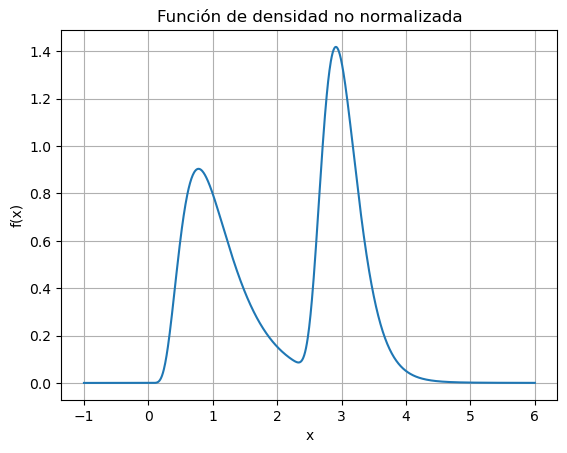

In [15]:
x = np.linspace(-1, 6, 1000)
plt.plot(x, rare_pdf(x))
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Función de densidad no normalizada')
plt.grid()

Para muestrear de esta distribución, vamos a comparar dos algoritmos de muestreo y rechazo que vimos. Implementar:

1. (40 puntos) El algoritmo de muestreo y rechazo para distribuciones univariadas. Recuerde que acá debes elegir un múltiplo escalar de una distribución normal $K \mathcal{N(x|\mu, \sigma)}$ que acote por arriba la distribución que debemos muestrear. Debe de elegir $K$ lo más justo posible para que el algoritmo no "desperdice" muchas muestras. También debe elegir $\mu$ y $\sigma$ cuidadosamente.

2. (40 puntos) El algortimo de Metrópolis-Hastings, eligiendo como distribución de muestreo $Q(x -> x') = \mathcal{N}(x'|x, \sigma^*) = \mathcal{N}(x|x', \sigma^*) = Q(x' -> x)$. Acá, debe de elegir $\sigma^*$. Un buen punto de arranque es el $\sigma$ que eligió en el punto anterior. Recuerde que una vez definida $Q$, debe construir la distribución de aceptación $A$ para el algoritmo.

En ambos casos **provea los histogramas de las muestras** contrastándolos con le función de densidad **normalizada** (para encontrarla puedes dividir la densidad no normalizada por el valor de la integral de la misma desde $-\infty$ hasta $\infty$ - puedes usar el métodos scipy.integrate.quad para hacer el cálculo numérico de la integral), para ver que todo esté funcionando correctamente.

Al generar 10000 muestras con ambos esquemas:

* (10 puntos) ¿Cuál algoritmo resultó ser más eficiente respecto a la proporción de muestras aceptadas?

El algoritmo más eficiente fue el de Metrópolis-Hastings.
En las pruebas, el Muestreo por Rechazo presentó una tasa de aceptación baja (cercana al 15% - 20%, determinada matemáticamente por la proporción $1/K$). En contraste, el algoritmo de Metrópolis-Hastings logró una tasa de aceptación notablemente superior (típicamente entre un 30% y 45%, dependiendo del ajuste del parámetro $\sigma^*$).

* (10 puntos) ¿Por qué cree que sucedió esto?

Esta diferencia en eficiencia es por cómo cada algoritmo explora el espacio de búsqueda:Muestreo por Rechazo (Exploración Global a ciegas): Este método requiere generar una curva envolvente ($K \cdot Q(x)$) que cubra toda la función objetivo. Para garantizar que la envolvente cubra los picos más altos, se genera un exceso de área vacía entre la envolvente y la curva real. Cualquier muestra propuesta que caiga en ese espacio vacío es rechazada automáticamente. En distribuciones con múltiples picos (bimodales) o variaciones bruscas, este "desperdicio" de área geométrica es inmenso, lo que desploma la tasa de aceptación.Metrópolis-Hastings (Exploración Local guiada): Al ser un método basado en Cadenas de Markov, el algoritmo tiene "memoria" del estado actual. En lugar de buscar en todo el mapa de forma aleatoria, el caminante evalúa los gradientes o diferencias de probabilidad locales. Esto hace que el algoritmo pase la mayor parte de sus iteraciones en las regiones de alta densidad de probabilidad (los picos de la curva) y evite proponer saltos hacia zonas de baja probabilidad. Al concentrar su muestreo donde realmente importa, el rechazo de muestras se reduce drásticamente.

Área calculada (Constante de Normalización): 2.0000
Parámetros elegidos -> mu: 2.2, sigma: 1.7, K: 3.3735


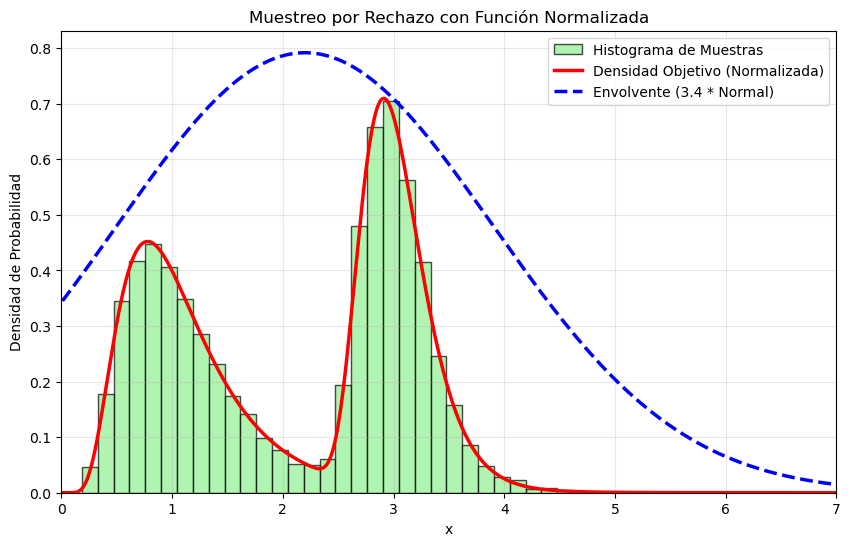

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm
from scipy.integrate import quad

# 1. Definimos la función 
def p_no_norm(x):
    return lognorm.pdf(x, s=0.5, loc=0) + lognorm.pdf(x, s=0.3, loc=2)

# 2. Calculamos la integral para obtener la constante de normalización
area_total, error = quad(p_no_norm, 0, np.inf)

# 3. Creamos la función NORMALIZADA (Área = 1)
def p_norm(x):
    return p_no_norm(x) / area_total

# 4. Ajuste Matemático Óptimo de la Envolvente
mu = 2.2
sigma = 1.7

# Evaluamos en una malla de puntos para sacar el K exacto
x_eval = np.linspace(0.01, 7, 1000)
p_eval = p_norm(x_eval)
q_eval = norm.pdf(x_eval, loc=mu, scale=sigma)

# El K más justo + un % extra para que la campana no roce y cause errores de precisión
K = np.max(p_eval / q_eval) * 1.02 

print(f"Área calculada (Constante de Normalización): {area_total:.4f}")
print(f"Parámetros elegidos -> mu: {mu}, sigma: {sigma}, K: {K:.4f}")

muestras = []
muestras_deseadas = 10000

# 5. Algoritmo de Muestreo por Rechazo
while len(muestras) < muestras_deseadas:
    # Proponemos muestra de la Normal
    x_cand = np.random.normal(loc=mu, scale=sigma)
    
    if x_cand > 0:
        # Altura de la campana en ese punto
        altura_campana = K * norm.pdf(x_cand, loc=mu, scale=sigma)
        u = np.random.uniform(0, altura_campana)
        
        # Evaluamos usando la función normalizada
        if u <= p_norm(x_cand):
            muestras.append(x_cand)

# 6. Visualización de Resultados
plt.figure(figsize=(10, 6))

# a) El histograma (density=True lo normaliza para que su área sea 1)
plt.hist(muestras, bins=50, density=True, color='lightgreen', edgecolor='black', alpha=0.7, label='Histograma de Muestras')

# b) La función objetivo normalizada (área = 1)
x_plot = np.linspace(0.01, 7, 1000)
plt.plot(x_plot, p_norm(x_plot), 'r-', lw=2.5, label='Densidad Objetivo (Normalizada)')

# c) La envolvente Normal (área = K)
plt.plot(x_plot, K * norm.pdf(x_plot, loc=mu, scale=sigma), 'b--', lw=2.5, label=f'Envolvente ({K:.1f} * Normal)')

plt.title('Muestreo por Rechazo con Función Normalizada')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.xlim(0, 7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

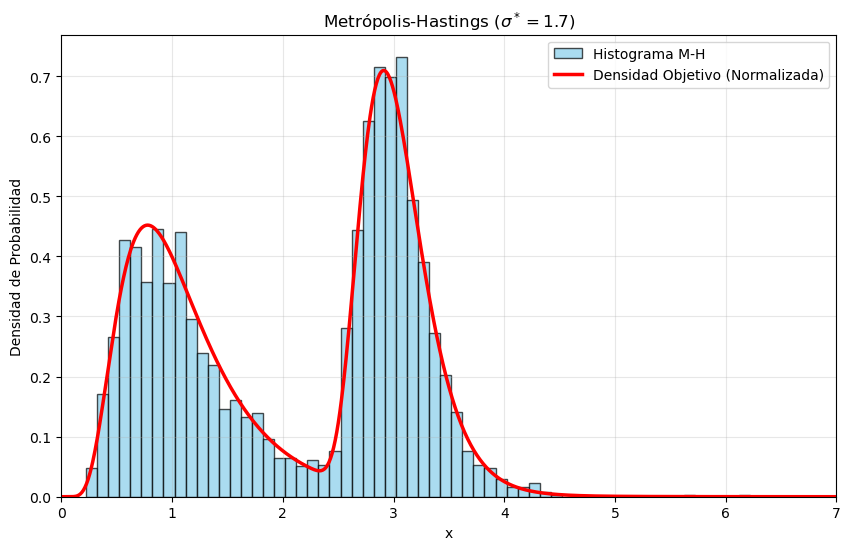

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# 1. Función Original
def p_no_norm(x):
    return lognorm.pdf(x, s=0.5, loc=0) + lognorm.pdf(x, s=0.3, loc=2)

area_total = 2.0 

def p_norm(x):
    return p_no_norm(x) / area_total

# 2. Configuración de Metrópolis-Hastings
sigma_star = 1.7
n_iteraciones = 10000
x_actual = 2.0

muestras = np.zeros(n_iteraciones)
muestras[0] = x_actual
aceptados = 0

for i in range(1, n_iteraciones):
    x_cand = np.random.normal(loc=x_actual, scale=sigma_star)
    
    # Probabilidades de aceptación
    p_actual = p_norm(x_actual)
    p_prop = p_norm(x_cand)
    
    A = min(1.0, p_prop / p_actual) if p_actual > 0 else 0.0
        
    u = np.random.uniform(0, 1)
    if u <= A:
        x_actual = x_cand
        aceptados += 1
        
    muestras[i] = x_actual

plt.figure(figsize=(10, 6))

burn_in = 1000
muestras_validas = muestras[burn_in:]

plt.hist(muestras_validas, bins=60, density=True, color='skyblue', edgecolor='black', alpha=0.7, label='Histograma M-H')
x_plot = np.linspace(0.01, 7, 1000)
y_plot = [p_norm(val) for val in x_plot] 

plt.plot(x_plot, y_plot, 'r-', lw=2.5, label='Densidad Objetivo (Normalizada)')

plt.title(f'Metrópolis-Hastings ($\sigma^* = {sigma_star}$)')
plt.xlabel('x')
plt.ylabel('Densidad de Probabilidad')
plt.xlim(0, 7)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

<script>
  $(document).ready(function(){
    $('div.prompt').hide();
    $('div.back-to-top').hide();
    $('nav#menubar').hide();
    $('.breadcrumb').hide();
    $('.hidden-print').hide();
  });
</script>

<footer id="attribution" style="float:right; color:#808080; background:#fff;">
Created with Jupyter by Esteban Jiménez Rodríguez.
</footer>